# Tema 2 - Dispositivos Semiconductores
**Electrónica General — 2.º GIERM**

Contenido:
1. Unión PN: potencial de contacto, zona espacial de carga, polarización directa e inversa, ruptura
2. JFET: canal N/P, pinch-off, regiones de operación
3. MOSFET: acumulación, deplección, inversión, regiones triodo y saturación
4. Ejercicios resueltos y catálogo de problemas tipo
5. Resumen de fórmulas clave

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# Paleta de colores
COLOR_PRINCIPAL = '#2171b5'
COLOR_FIJO      = '#636363'
COLOR_PUNTO     = '#238b45'
COLOR_ROJO      = '#cb181d'
COLOR_NARANJA   = '#ff7f00'
COLOR_MORADO    = '#6a3d9a'
COLOR_CLARO     = '#a6cee3'

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

---
## 1. La unión PN

Cuando se ponen en contacto un semiconductor tipo **P** (mayoritariamente huecos) y uno tipo **N**
(mayoritariamente electrones), se produce una **difusión** de portadores que crea la
**zona espacial de carga** (ZEC) o zona de deplección.

### 1.1 Potencial de contacto $V_0$

El equilibrio termodinámico genera un campo eléctrico interno y un potencial de contacto:

$$\boxed{V_0 = \phi_T \ln\!\left(\frac{N_A \, N_D}{n_i^2}\right)}$$

donde $\phi_T = kT/q \approx 26\,\text{mV}$ a temperatura ambiente ($T = 300\,\text{K}$).

| Símbolo | Significado | Unidades |
|---------|-------------|----------|
| $N_A$ | Concentración de aceptores (zona P) | cm$^{-3}$ |
| $N_D$ | Concentración de donadores (zona N) | cm$^{-3}$ |
| $n_i$ | Concentración intrínseca ($1.5 \times 10^{10}$ en Si) | cm$^{-3}$ |

### 1.2 Zona espacial de carga (ZEC)

La ZEC es la región desprovista de portadores móviles que rodea la unión.
Su anchura total $W$ depende de la polarización aplicada $v_D$:

$$W = \sqrt{\frac{2\,\varepsilon_s}{q}\left(\frac{1}{N_A}+\frac{1}{N_D}\right)(V_0 - v_D)}$$

- **Polarización directa** ($v_D > 0$): la ZEC se estrecha, fluye corriente.
- **Polarización inversa** ($v_D < 0$): la ZEC se ensancha, corriente despreciable ($\approx I_0$).

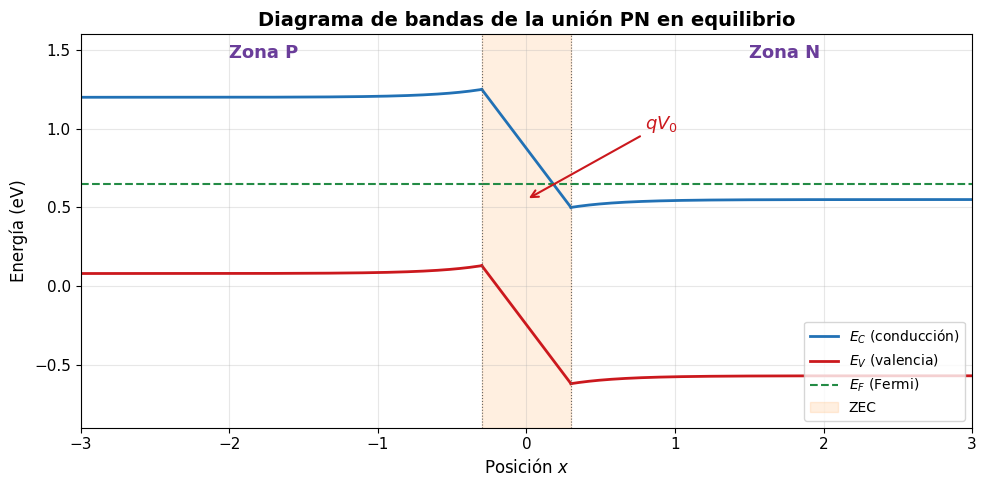

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))

# Banda de conduccion y valencia - zona P
x_p = np.linspace(-3, -0.3, 200)
Ec_p = 1.2 + 0.05 * np.exp(3 * (x_p + 0.3))
Ev_p = Ec_p - 1.12
Ef_p = np.full_like(x_p, 0.65)

# Banda de conduccion y valencia - zona N
x_n = np.linspace(0.3, 3, 200)
Ec_n = 0.55 - 0.05 * np.exp(-3 * (x_n - 0.3))
Ev_n = Ec_n - 1.12
Ef_n = np.full_like(x_n, 0.65)

# Zona de deplexion
x_d = np.linspace(-0.3, 0.3, 100)
Ec_d = np.linspace(Ec_p[-1], Ec_n[0], 100)
Ev_d = Ec_d - 1.12
Ef_d = np.full_like(x_d, 0.65)

# Dibujar bandas
ax.plot(x_p, Ec_p, color=COLOR_PRINCIPAL, lw=2, label='$E_C$ (conducción)')
ax.plot(x_p, Ev_p, color=COLOR_ROJO, lw=2, label='$E_V$ (valencia)')
ax.plot(x_p, Ef_p, color=COLOR_PUNTO, lw=1.5, ls='--', label='$E_F$ (Fermi)')

ax.plot(x_d, Ec_d, color=COLOR_PRINCIPAL, lw=2)
ax.plot(x_d, Ev_d, color=COLOR_ROJO, lw=2)
ax.plot(x_d, Ef_d, color=COLOR_PUNTO, lw=1.5, ls='--')

ax.plot(x_n, Ec_n, color=COLOR_PRINCIPAL, lw=2)
ax.plot(x_n, Ev_n, color=COLOR_ROJO, lw=2)
ax.plot(x_n, Ef_n, color=COLOR_PUNTO, lw=1.5, ls='--')

# Zona deplexion sombreada
ax.axvspan(-0.3, 0.3, alpha=0.12, color=COLOR_NARANJA, label='ZEC')
ax.axvline(-0.3, color=COLOR_FIJO, ls=':', lw=0.8)
ax.axvline(0.3, color=COLOR_FIJO, ls=':', lw=0.8)

# Etiquetas
ax.text(-2.0, 1.45, 'Zona P', fontsize=13, fontweight='bold', color=COLOR_MORADO)
ax.text(1.5, 1.45, 'Zona N', fontsize=13, fontweight='bold', color=COLOR_MORADO)
ax.annotate('$qV_0$', xy=(0, 0.55), xytext=(0.8, 1.0),
           fontsize=13, color=COLOR_ROJO, fontweight='bold',
           arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=1.5))

ax.set_xlabel('Posición $x$', fontsize=12)
ax.set_ylabel('Energía (eV)', fontsize=12)
ax.set_title('Diagrama de bandas de la unión PN en equilibrio', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(-3, 3)
ax.set_ylim(-0.9, 1.6)
plt.tight_layout()
plt.show()

### 1.3 Ecuación del diodo (Shockley)

La relación corriente-tensión del diodo ideal es:

$$\boxed{i_D = I_0\!\left(e^{v_D / \phi_T} - 1\right)}$$

$$\boxed{\phi_T = \frac{kT}{q} \approx 26\,\text{mV} \quad (T = 300\,\text{K})}$$

- $I_0$: corriente de saturación inversa (del orden de pA en diodos de Si).
- En directa: $i_D$ crece exponencialmente con $v_D$.
- En inversa: $i_D \approx -I_0$ (muy pequeña).

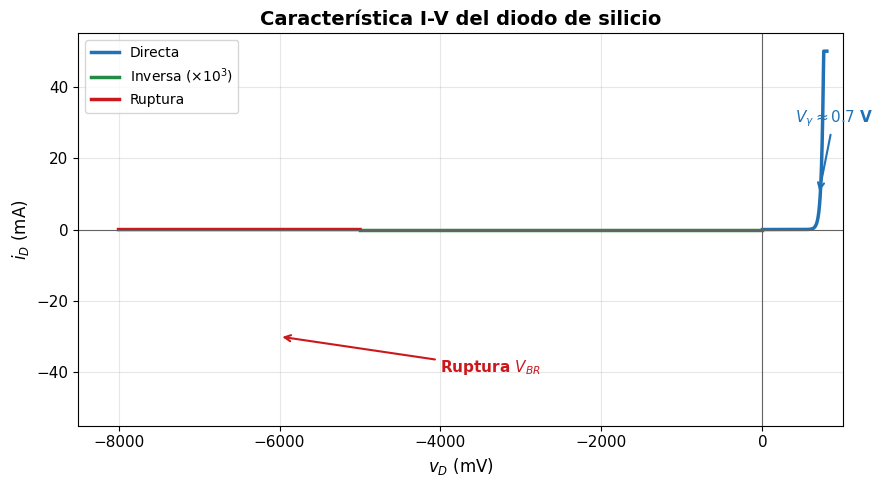

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

I_0 = 1e-14        # A (corriente de saturacion)
phi_T = 26e-3       # V (potencial termico)

# Polarizacion directa
vd_fwd = np.linspace(0, 0.8, 500)
id_fwd = I_0 * (np.exp(vd_fwd / phi_T) - 1)
id_fwd = np.clip(id_fwd, 0, 0.05)  # limitar para visualizacion

# Polarizacion inversa
vd_rev = np.linspace(-5, 0, 300)
id_rev = I_0 * (np.exp(vd_rev / phi_T) - 1)

# Zona de ruptura (modelo simplificado)
vd_break = np.linspace(-8, -5, 200)
id_break = -I_0 * np.exp(-(vd_break + 5) / 0.15)
id_break = np.clip(id_break, -0.05, 0)

# Curva completa
ax.plot(vd_fwd * 1e3, id_fwd * 1e3, color=COLOR_PRINCIPAL, lw=2.5, label='Directa')
ax.plot(vd_rev * 1e3, id_rev * 1e6, color=COLOR_PUNTO, lw=2.5, label='Inversa ($\\times 10^3$)')
ax.plot(vd_break * 1e3, id_break * 1e3, color=COLOR_ROJO, lw=2.5, label='Ruptura')

# Ejes de referencia
ax.axhline(0, color=COLOR_FIJO, lw=0.8)
ax.axvline(0, color=COLOR_FIJO, lw=0.8)

# Anotar puntos clave
ax.annotate('$V_{\\gamma} \\approx 0.7$ V', xy=(700, 10), xytext=(400, 30),
           fontsize=11, color=COLOR_PRINCIPAL, fontweight='bold',
           arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=1.5))
ax.annotate('Ruptura $V_{BR}$', xy=(-6000, -30), xytext=(-4000, -40),
           fontsize=11, color=COLOR_ROJO, fontweight='bold',
           arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=1.5))

ax.set_xlabel('$v_D$ (mV)', fontsize=12)
ax.set_ylabel('$i_D$ (mA)', fontsize=12)
ax.set_title('Característica I-V del diodo de silicio', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-8500, 1000)
ax.set_ylim(-55, 55)
plt.tight_layout()
plt.show()

### 1.4 Ruptura de la unión PN

Cuando la tensión inversa supera $V_{BR}$, la corriente inversa aumenta drásticamente.
Existen dos mecanismos:

| Mecanismo | Causa | Dopaje típico | $V_{BR}$ |
|-----------|-------|-------------|----------|
| **Zener** | Efecto túnel (campo eléctrico rompe enlaces) | Alto ($> 10^{18}$) | $< 5$ V |
| **Avalancha** | Ionización por impacto en cascada | Bajo-moderado | $> 7$ V |

> **Nota:** Entre 5 V y 7 V ambos mecanismos coexisten.

---
## 2. Transistor JFET

El **JFET** (Junction Field-Effect Transistor) es un dispositivo de tres terminales
(puerta G, drenador D, fuente S) controlado por tensión.

### 2.1 Estructura y principio de funcionamiento

- **Canal N**: portadores mayoritarios son electrones; la puerta es una unión PN en inversa.
- **Canal P**: portadores mayoritarios son huecos; polaridades invertidas.

Al aplicar $v_{GS} < 0$ (canal N) la ZEC de la puerta se ensancha y **estrangula** el canal.

### 2.2 Pinch-off y regiones de operación

| Región | Condición | Comportamiento |
|--------|----------|----------------|
| **Óhmica (triodo)** | $v_{DS} < v_{GS} - V_P$ | Canal sin estrangular; $i_D \propto v_{DS}$ |
| **Saturación (pinch-off)** | $v_{DS} \geq v_{GS} - V_P$ | Canal estrangulado; $i_D \approx \text{cte}$ |
| **Corte** | $v_{GS} \leq V_P$ | $i_D = 0$ |

En saturación:

$$i_D = I_{DSS}\left(1 - \frac{v_{GS}}{V_P}\right)^2$$

donde $I_{DSS}$ es la corriente con $v_{GS} = 0$ y $V_P$ es la tensión de pinch-off (negativa para canal N).

---
## 3. Transistor MOSFET

El **MOSFET** (Metal-Oxide-Semiconductor FET) es el transistor más utilizado en
circuitos integrados. La puerta está **aislada** del canal por una capa de óxido ($\text{SiO}_2$).

### 3.1 Estructura MOS: acumulación, deplección, inversión

Para un NMOS sobre sustrato tipo P, al variar $v_{GS}$:

| Régimen | $v_{GS}$ | Superficie del semiconductor |
|---------|----------|------------------------------|
| **Acumulación** | $v_{GS} < 0$ | Huecos atraídos a la superficie |
| **Deplección** | $0 < v_{GS} < V_T$ | Huecos repelidos; zona de carga espacial |
| **Inversión** | $v_{GS} > V_T$ | Capa de electrones (canal N) en la superficie |

### 3.2 Regiones de operación del MOSFET

Una vez formado el canal ($v_{GS} > V_T$):

| Región | Condición | Ecuación de $i_D$ |
|--------|----------|-------------------|
| **Triodo** | $v_{DS} < v_{GS} - V_T$ | $i_D = K_n\left[(v_{GS}-V_T)v_{DS} - \frac{v_{DS}^2}{2}\right]$ |
| **Saturación** | $v_{DS} \geq v_{GS} - V_T$ | $\boxed{i_D = \frac{K_n}{2}(v_{GS} - V_T)^2}$ |
| **Corte** | $v_{GS} < V_T$ | $i_D = 0$ |

donde $K_n = \mu_n C_{ox} \frac{W}{L}$ es el parámetro de transconductancia.

Con modulación de longitud de canal ($\lambda$):

$$i_D = \frac{K_n}{2}(v_{GS} - V_T)^2(1 + \lambda\, v_{DS})$$

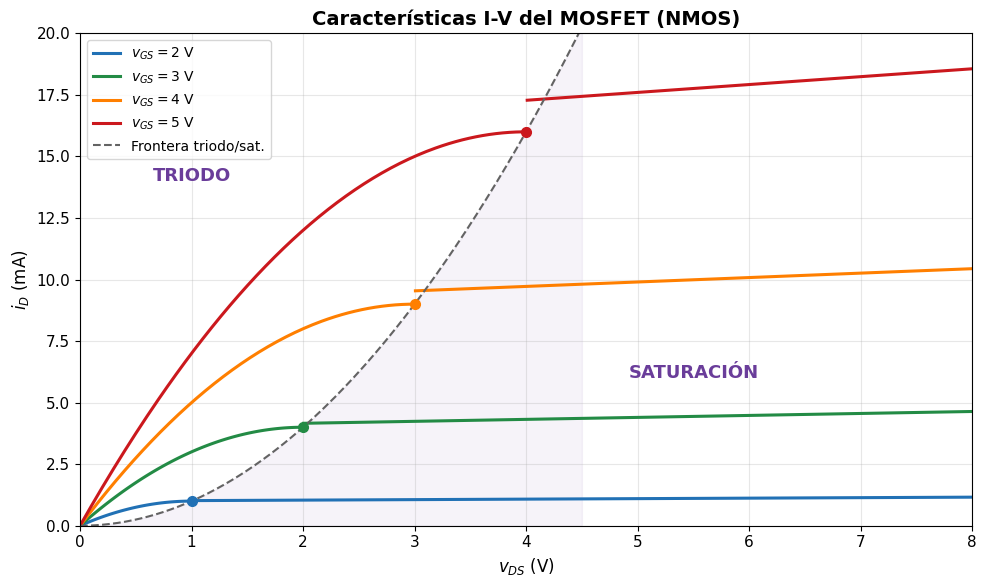

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Curva limite triodo-saturacion
vgs_vals = [2.0, 3.0, 4.0, 5.0]
VT = 1.0
Kn = 2e-3  # A/V^2
lam = 0.02  # modulacion canal

vds = np.linspace(0, 8, 400)

colors_curves = [COLOR_PRINCIPAL, COLOR_PUNTO, COLOR_NARANJA, COLOR_ROJO]

for vgs, col in zip(vgs_vals, colors_curves):
    vov = vgs - VT  # tension de overdrive
    # Triodo
    mask_tri = vds < vov
    id_tri = Kn * ((vgs - VT) * vds[mask_tri] - vds[mask_tri]**2 / 2)
    # Saturacion
    mask_sat = vds >= vov
    id_sat = (Kn / 2) * (vgs - VT)**2 * (1 + lam * vds[mask_sat])
    # Dibujar
    ax.plot(vds[mask_tri], id_tri * 1e3, color=col, lw=2.2)
    ax.plot(vds[mask_sat], id_sat * 1e3, color=col, lw=2.2,
            label=f'$v_{{GS}}={vgs:.0f}$ V')
    # Punto de transicion
    ax.plot(vov, (Kn / 2) * vov**2 * 1e3, 'o', color=col, ms=7, zorder=5)

# Curva frontera triodo/saturacion
vov_line = np.linspace(0, 4.5, 200)
id_line = (Kn / 2) * vov_line**2
ax.plot(vov_line, id_line * 1e3, '--', color=COLOR_FIJO, lw=1.5,
        label='Frontera triodo/sat.')
ax.fill_between(vov_line, id_line * 1e3, alpha=0.06, color=COLOR_MORADO)

# Etiquetas de regiones
ax.text(1.0, 14, 'TRIODO', fontsize=13, fontweight='bold',
        color=COLOR_MORADO, ha='center')
ax.text(5.5, 6, 'SATURACIÓN', fontsize=13, fontweight='bold',
        color=COLOR_MORADO, ha='center')

ax.set_xlabel('$v_{DS}$ (V)', fontsize=12)
ax.set_ylabel('$i_D$ (mA)', fontsize=12)
ax.set_title('Características I-V del MOSFET (NMOS)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(0, 8)
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()

### 3.3 Parámetros de pequeña señal del MOSFET

En el punto de operación (saturación), el modelo de pequeña señal se caracteriza por:

**Transconductancia:**

$$\boxed{g_m = K_n(v_{GS} - V_T) = \frac{2\,I_D}{V_{EFF}}}$$

donde $V_{EFF} = v_{GS} - V_T$ es la tensión de sobreexcitación (overdrive).

**Resistencia de salida:**

$$\boxed{r_o = \frac{1}{\lambda\,I_D}}$$

Estos parámetros definen la ganancia intrínseca del transistor: $A_v = g_m \cdot r_o$.

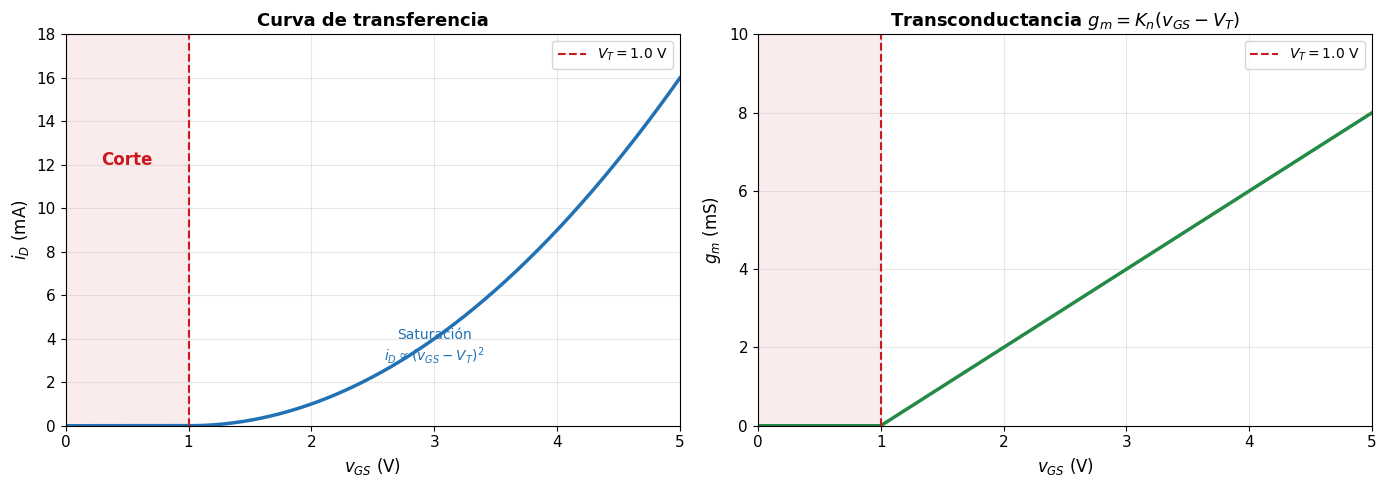

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel izquierdo: curva de transferencia ---
VT = 1.0
Kn = 2e-3
vgs_tf = np.linspace(0, 5, 400)
id_tf = np.where(vgs_tf > VT, (Kn / 2) * (vgs_tf - VT)**2, 0)

ax1.plot(vgs_tf, id_tf * 1e3, color=COLOR_PRINCIPAL, lw=2.5)
ax1.axvline(VT, color=COLOR_ROJO, ls='--', lw=1.5, label=f'$V_T = {VT}$ V')
ax1.fill_betweenx([0, 18], 0, VT, alpha=0.08, color=COLOR_ROJO)
ax1.text(0.5, 12, 'Corte', fontsize=12, ha='center', color=COLOR_ROJO, fontweight='bold')
ax1.text(3.0, 3, 'Saturación\n$i_D \\propto (v_{GS}-V_T)^2$', fontsize=10,
         ha='center', color=COLOR_PRINCIPAL)

ax1.set_xlabel('$v_{GS}$ (V)', fontsize=12)
ax1.set_ylabel('$i_D$ (mA)', fontsize=12)
ax1.set_title('Curva de transferencia', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(0, 5)
ax1.set_ylim(0, 18)

# --- Panel derecho: gm vs vgs ---
gm_vals = np.where(vgs_tf > VT, Kn * (vgs_tf - VT), 0)

ax2.plot(vgs_tf, gm_vals * 1e3, color=COLOR_PUNTO, lw=2.5)
ax2.axvline(VT, color=COLOR_ROJO, ls='--', lw=1.5, label=f'$V_T = {VT}$ V')
ax2.fill_betweenx([0, 10], 0, VT, alpha=0.08, color=COLOR_ROJO)

ax2.set_xlabel('$v_{GS}$ (V)', fontsize=12)
ax2.set_ylabel('$g_m$ (mS)', fontsize=12)
ax2.set_title('Transconductancia $g_m = K_n(v_{GS}-V_T)$', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim(0, 5)
ax2.set_ylim(0, 10)

plt.tight_layout()
plt.show()

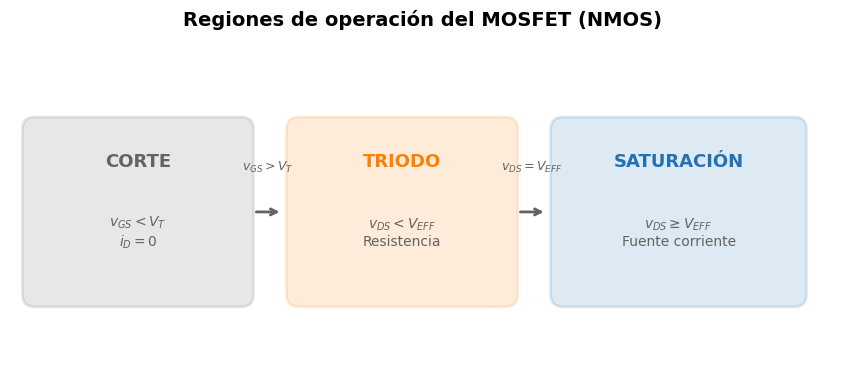

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Regiones de operación del MOSFET (NMOS)', fontsize=14, fontweight='bold', pad=15)

# Cajas de regiones
regions = [
    (0.3, 1.0, 2.5, 2.0, 'CORTE', '$v_{GS} < V_T$\n$i_D = 0$', COLOR_FIJO),
    (3.5, 1.0, 2.5, 2.0, 'TRIODO', '$v_{DS} < V_{EFF}$\nResistencia', COLOR_NARANJA),
    (6.7, 1.0, 2.8, 2.0, 'SATURACIÓN', '$v_{DS} \\geq V_{EFF}$\nFuente corriente', COLOR_PRINCIPAL),
]

for x, y, w, h, title, desc, col in regions:
    rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                          facecolor=col, alpha=0.15, edgecolor=col, lw=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.4, title, ha='center', va='center',
            fontsize=13, fontweight='bold', color=col)
    ax.text(x + w/2, y + h/2 - 0.25, desc, ha='center', va='center',
            fontsize=10, color=COLOR_FIJO)

# Flechas
ax.annotate('', xy=(3.3, 2.0), xytext=(2.95, 2.0),
           arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2))
ax.annotate('', xy=(6.5, 2.0), xytext=(6.15, 2.0),
           arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2))
ax.text(3.12, 2.5, '$v_{GS}>V_T$', fontsize=9, ha='center', color=COLOR_FIJO)
ax.text(6.32, 2.5, '$v_{DS}=V_{EFF}$', fontsize=9, ha='center', color=COLOR_FIJO)

plt.tight_layout()
plt.show()

---
## 4. Ejercicios resueltos

A continuación se resuelven 4 ejercicios representativos que cubren los conceptos
fundamentales de dispositivos semiconductores.

### Ejercicio 1: Potencial de contacto de una unión PN

**Enunciado:** Calcular el potencial de contacto $V_0$ de una unión PN de silicio a $T = 300$ K
con $N_A = 10^{17}\,\text{cm}^{-3}$ y $N_D = 10^{16}\,\text{cm}^{-3}$.
Dato: $n_i = 1.5 \times 10^{10}\,\text{cm}^{-3}$.

**Solución:**

$$\phi_T = \frac{kT}{q} = 26\,\text{mV}$$

$$V_0 = \phi_T \ln\!\left(\frac{N_A N_D}{n_i^2}\right) = 0.026 \cdot \ln\!\left(\frac{10^{17} \cdot 10^{16}}{(1.5 \times 10^{10})^2}\right)$$

$$V_0 = 0.026 \cdot \ln(4.44 \times 10^{12}) = 0.026 \times 29.12 = 0.757\,\text{V}$$

$$\boxed{V_0 \approx 0.76\,\text{V}}$$

In [7]:
# Ejercicio 1: Verificacion numerica
k = 1.381e-23      # J/K
T = 300             # K
q = 1.602e-19       # C
phi_T = k * T / q

NA = 1e17           # cm^-3
ND = 1e16           # cm^-3
ni = 1.5e10         # cm^-3

V0 = phi_T * np.log(NA * ND / ni**2)

print(f'phi_T = {phi_T*1e3:.2f} mV')
print(f'V0    = {V0:.4f} V')
print(f'V0    = {V0:.2f} V (redondeado)')

phi_T = 25.86 mV
V0    = 0.7532 V
V0    = 0.75 V (redondeado)


### Ejercicio 2: Corriente del diodo en directa

**Enunciado:** Un diodo de silicio tiene $I_0 = 10^{-14}$ A. Calcular la corriente
cuando $v_D = 0.65$ V a $T = 300$ K.

**Solución:**

$$i_D = I_0\left(e^{v_D / \phi_T} - 1\right) = 10^{-14} \cdot \left(e^{0.65/0.026} - 1\right)$$

$$i_D = 10^{-14} \cdot \left(e^{25} - 1\right) = 10^{-14} \cdot 7.2 \times 10^{10}$$

$$\boxed{i_D \approx 0.72\,\text{mA}}$$

In [8]:
# Ejercicio 2: Verificacion numerica
I_0 = 1e-14         # A
phi_T_val = 26e-3    # V
vD = 0.65            # V

iD = I_0 * (np.exp(vD / phi_T_val) - 1)

print(f'Exponente: v_D/phi_T = {vD/phi_T_val:.2f}')
print(f'i_D = {iD:.4e} A')
print(f'i_D = {iD*1e3:.3f} mA')

Exponente: v_D/phi_T = 25.00
i_D = 7.2005e-04 A
i_D = 0.720 mA


### Ejercicio 3: Punto de operación del MOSFET

**Enunciado:** Un NMOS tiene $K_n = 2\,\text{mA/V}^2$, $V_T = 1\,\text{V}$ y $\lambda = 0$.
Si $v_{GS} = 3\,\text{V}$ y $v_{DS} = 4\,\text{V}$, determinar la región de operación y $i_D$.

**Solución:**

1. Verificar canal: $v_{GS} = 3 > V_T = 1$ V $\Rightarrow$ canal formado.
2. Tensión de overdrive: $V_{EFF} = v_{GS} - V_T = 3 - 1 = 2$ V.
3. Comprobar región: $v_{DS} = 4 \geq V_{EFF} = 2$ $\Rightarrow$ **Saturación**.
4. Corriente:

$$i_D = \frac{K_n}{2}(v_{GS} - V_T)^2 = \frac{2 \times 10^{-3}}{2}(2)^2 = 4\,\text{mA}$$

$$\boxed{i_D = 4\,\text{mA} \quad \text{(saturación)}}$$

In [9]:
# Ejercicio 3: Verificacion numerica
Kn = 2e-3    # A/V^2
VT = 1.0     # V
vGS = 3.0    # V
vDS = 4.0    # V
lam = 0      # sin modulacion

V_EFF = vGS - VT
print(f'V_EFF = v_GS - V_T = {V_EFF:.1f} V')

if vGS < VT:
    region = 'Corte'
    iD = 0
elif vDS < V_EFF:
    region = 'Triodo'
    iD = Kn * ((vGS - VT) * vDS - vDS**2 / 2)
else:
    region = 'Saturacion'
    iD = (Kn / 2) * (vGS - VT)**2 * (1 + lam * vDS)

print(f'v_DS = {vDS:.1f} V >= V_EFF = {V_EFF:.1f} V')
print(f'Region: {region}')
print(f'i_D = {iD*1e3:.2f} mA')

V_EFF = v_GS - V_T = 2.0 V
v_DS = 4.0 V >= V_EFF = 2.0 V
Region: Saturacion
i_D = 4.00 mA


### Ejercicio 4: Parámetros de pequeña señal

**Enunciado:** Para el MOSFET del ejercicio anterior, con $\lambda = 0.02\,\text{V}^{-1}$,
calcular $g_m$ y $r_o$.

**Solución:**

Con $I_D = 4\,\text{mA}$ y $V_{EFF} = 2\,\text{V}$:

$$g_m = \frac{2\,I_D}{V_{EFF}} = \frac{2 \times 4 \times 10^{-3}}{2} = 4\,\text{mS}$$

$$r_o = \frac{1}{\lambda\,I_D} = \frac{1}{0.02 \times 4 \times 10^{-3}} = 12.5\,\text{k}\Omega$$

Ganancia intrínseca:

$$A_v = g_m \cdot r_o = 4 \times 10^{-3} \times 12500 = 50$$

$$\boxed{g_m = 4\,\text{mS}, \quad r_o = 12.5\,\text{k}\Omega, \quad A_v = 50}$$

In [10]:
# Ejercicio 4: Verificacion numerica
ID = 4e-3        # A
V_EFF = 2.0      # V
lam_val = 0.02   # V^-1

gm = 2 * ID / V_EFF
ro = 1 / (lam_val * ID)
Av = gm * ro

print(f'g_m = {gm*1e3:.1f} mS')
print(f'r_o = {ro*1e-3:.1f} kOhm')
print(f'A_v = g_m * r_o = {Av:.0f}')

g_m = 4.0 mS
r_o = 12.5 kOhm
A_v = g_m * r_o = 50


---
## 5. Catálogo de problemas tipo

| # | Tipo de problema | Conceptos clave | Dificultad |
|---|-----------------|-----------------|------------|
| 1 | **Cálculo de $V_0$ y anchura de ZEC** | $V_0 = \phi_T\ln(N_AN_D/n_i^2)$, anchura $W$ | Media |
| 2 | **Punto de operación del diodo** | Ecuación de Shockley, modelo exponencial, recta de carga | Media |
| 3 | **Identificar región del MOSFET** | Comparar $v_{DS}$ con $V_{EFF}$, calcular $i_D$ | Básica |
| 4 | **Diseño de punto Q del MOSFET** | Dado $I_D$ objetivo, encontrar $v_{GS}$ y $R_D$ | Media-Alta |
| 5 | **Parámetros pequeña señal y ganancia** | $g_m$, $r_o$, $A_v = g_m r_o$, modelo $\pi$ | Alta |

---
## 6. Resumen de fórmulas clave

### Unión PN

$$\boxed{\phi_T = \frac{kT}{q} \approx 26\,\text{mV}}$$

$$\boxed{V_0 = \phi_T \ln\!\left(\frac{N_A N_D}{n_i^2}\right)}$$

$$\boxed{i_D = I_0\left(e^{v_D/\phi_T} - 1\right)}$$

### JFET (saturación)

$$i_D = I_{DSS}\left(1 - \frac{v_{GS}}{V_P}\right)^2$$

### MOSFET

$$\boxed{i_D = \frac{K_n}{2}(v_{GS} - V_T)^2 \quad \text{(saturación)}}$$

$$\boxed{g_m = \frac{2\,I_D}{V_{EFF}}} \qquad \boxed{r_o = \frac{1}{\lambda\,I_D}}$$

$$A_v = g_m \cdot r_o \quad \text{(ganancia intrínseca)}$$